In [19]:
import os
import torch
import pandas as pd
import random
import time
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import display, clear_output


print(os.path.join('..','data'))
os.makedirs(os.path.join('..','data'),exist_ok=True)
print(os.getcwd())

..\data
e:\Documents\learning\AI-Learning\d2l


In [20]:
train_datas=pd.read_csv('./House Price Forecast/california-house-price/housing_train.csv')
test_datas=pd.read_csv('./House Price Forecast/california-house-price/housing_test.csv')

In [21]:
print(train_datas.tail(1))
print(test_datas.tail(1))
print(train_datas.shape,test_datas.shape)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
14447    -119.08     36.21                20.0       1911.0           389.0   

       population  households  median_income  median_house_value  \
14447      1241.0       348.0         2.5156             59300.0   

      ocean_proximity  
14447          INLAND  
        Id  longitude  latitude  housing_median_age  total_rooms  \
6191  6191    -118.49     34.27                33.0       3047.0   

      total_bedrooms  population  households  median_income ocean_proximity  
6191           527.0      1578.0       507.0           4.58       <1H OCEAN  
(14448, 10) (6192, 10)


In [22]:
# print(train_datas)
#分离特征和标签
features,labels=pd.concat((train_datas.iloc[:,:-2],train_datas.iloc[:,-1]),axis=1),train_datas.iloc[:,-2]
features=pd.concat((features,test_datas.iloc[:,1:]),axis=0)
labels=labels.astype('float32')

In [23]:
print(features.shape)
print(labels.shape)
print(features.iloc[[1,2,3,4],[-3,-2,-1]],labels.iloc[1:5])

(20640, 9)
(14448,)
   households  median_income ocean_proximity
1       812.0         3.5255          INLAND
2       173.0         1.9728          INLAND
3       340.0         6.9133       <1H OCEAN
4       382.0         2.6768        NEAR BAY 1    132100.0
2     97900.0
3    274100.0
4    182300.0
Name: median_house_value, dtype: float32


In [24]:
numeric_features=features.dtypes[features.dtypes!='object'].index
print(numeric_features)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')


In [25]:

features[numeric_features]=features[numeric_features].apply(
    lambda x:(x-x.mean())/(x.std())
)

features[numeric_features]=features[numeric_features].fillna(0)
features=pd.get_dummies(features,dummy_na=True)
features=features.astype('float32')

In [26]:
print(features.tail(2))
print(features.shape)

      longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
6190   0.598795 -0.731225            1.856137    -0.198368       -0.239379   
6191   0.538901 -0.637590            0.346470     0.188501       -0.025797   

      population  households  median_income  ocean_proximity_<1H OCEAN  \
6190   -0.464896   -0.302199       0.199666                        1.0   
6191    0.134683    0.019513       0.373366                        1.0   

      ocean_proximity_INLAND  ocean_proximity_ISLAND  \
6190                     0.0                     0.0   
6191                     0.0                     0.0   

      ocean_proximity_NEAR BAY  ocean_proximity_NEAR OCEAN  \
6190                       0.0                         0.0   
6191                       0.0                         0.0   

      ocean_proximity_nan  
6190                  0.0  
6191                  0.0  
(20640, 14)


In [27]:
train_features=pd.concat((features.iloc[:labels.shape[0],:],labels),axis=1)
print(train_features.shape)
test_features=features.iloc[labels.shape[0]:,:]
print(test_features.shape)

(14448, 15)
(6192, 14)


In [28]:
print(train_features.dtypes)

longitude                     float32
latitude                      float32
housing_median_age            float32
total_rooms                   float32
total_bedrooms                float32
population                    float32
households                    float32
median_income                 float32
ocean_proximity_<1H OCEAN     float32
ocean_proximity_INLAND        float32
ocean_proximity_ISLAND        float32
ocean_proximity_NEAR BAY      float32
ocean_proximity_NEAR OCEAN    float32
ocean_proximity_nan           float32
median_house_value            float32
dtype: object


In [29]:
def get_k_fold_data(k,i,x:torch.Tensor,y:torch.Tensor):
    fold_size=x.shape[0]//k
    x_train,y_train,x_valid,y_valid=None,None,None,None
    for j in range(k):
        idx=slice(j*fold_size,(j+1)*fold_size)
        x_part,y_part=x[idx,:],y[idx]
        if j!=i:
            if x_train is None:
                x_train,y_train=x_part,y_part
            else:
                x_train=torch.cat((x_train,x_part),dim=0)
                y_train=torch.cat((y_train,y_part),dim=0)
        else:
            x_valid,y_valid=x_part,y_part
    return x_train,y_train,x_valid,y_valid

In [30]:
a=torch.randn(100,10)
b=torch.randn(100)
x_train,y_train,x_valid,y_valid=get_k_fold_data(5,0,a,b)
print(x_train.shape,y_train.shape)
print(x_valid.shape,y_valid.shape)

torch.Size([80, 10]) torch.Size([80])
torch.Size([20, 10]) torch.Size([20])


In [31]:
train_features=torch.tensor(train_features.values,dtype=torch.float32)
test_features=torch.tensor(test_features.values,dtype=torch.float32)
train_features=train_features[torch.randperm(train_features.shape[0])]
x,y=train_features[:,:-1],train_features[:,-1]

In [32]:
loss=torch.nn.MSELoss()

in_features=train_features.shape[1]-1


In [50]:

def _init_weights(m):
    if isinstance(m,torch.nn.Linear):
        torch.nn.init.kaiming_normal_(m.weight)
        torch.nn.init.zeros_(m.bias)
    elif isinstance(m,torch.nn.BatchNorm1d):
        torch.nn.init.ones_(m.weight)
        torch.nn.init.zeros_(m.bias)

class Net(torch.nn.Module):
    def __init__(self,in_features,depth=[128,64,32,16,1]):
        super().__init__()
        layers=[torch.nn.Linear(in_features,depth[0]),
                    torch.nn.ReLU(),
                    torch.nn.BatchNorm1d(depth[0]),
                    # torch.nn.Dropout(0.2)
                    ]
        for i in range(len(depth)-1):
            if i==len(depth)-2:
                layers.append(torch.nn.Linear(depth[i],depth[i+1]))
                break
            layers.append(torch.nn.Linear(depth[i],depth[i+1]))
            layers.append(torch.nn.ReLU())
            layers.append(torch.nn.BatchNorm1d(depth[i+1]))
            # layers.append(torch.nn.Dropout(0.5))
        
        self.sequential=torch.nn.Sequential(*layers)
        self.apply(_init_weights)

    def forward(self,x):
        return self.sequential(x)



In [51]:
net=Net(in_features)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net=net.to(device)

In [52]:
print(net)

Net(
  (sequential): Sequential(
    (0): Linear(in_features=14, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Linear(in_features=32, out_features=16, bias=True)
    (10): ReLU()
    (11): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [ ]:
def log_rmse(net, features, labels):
    # 为了在取对数时进一步稳定该值，将小于1的值设置为1
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds),
                           torch.log(labels)))
    return rmse.item()

class ArrayDataset(Dataset):
    def __init__(self, features, labels=None):
        self.features = features
        self.labels = labels
        
    def __len__(self):
        return len(self.features)
    def __getitem__(self, idx):
        if self.labels is not None:
            self.labels=self.labels
            return self.features[idx], self.labels[idx]
        else:
            return self.features[idx]
class Animator:
    def __init__(self, xlabel='epoch', ylabel='loss'):
        self.xlabel = xlabel
        self.ylabel = ylabel
        self.xs, self.ys = [], []
        
        # 设置 Jupyter 绘图风格
        plt.style.use('seaborn-v0_8-whitegrid') 

    def add(self, x, y):
        self.xs.append(x)
        self.ys.append(y)

    def plot(self):
        # 1. 清空当前单元格的输出，wait=True 防止闪烁
        clear_output(wait=True)
        
        # 2. 如果没有数据，直接返回
        if len(self.xs) == 0:
            return

        # 3. 创建新的画布
        plt.figure(figsize=(6, 4))
        
        # 4. 绘图
        epochs = range(1, len(self.xs) + 1)
        plt.plot(epochs, self.xs, label='Train Loss', marker='o', markersize=4, linewidth=2)
        plt.plot(epochs, self.ys, label='Valid Loss', marker='x', markersize=6, linewidth=2)
        
        # 5. 添加标题和标签
        plt.xlabel(self.xlabel)
        plt.ylabel(self.ylabel)
        plt.title('Real-time Training Progress')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        
        # 6. 显示图像
        plt.show()
    

def train(net,k_fold, train_iter,test_iter,
          num_epochs, learning_rate, weight_decay,temperature=50):
    train_ls, test_ls = [], []
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 这里使用的是Adam优化算法
    optimizer = torch.optim.Adam(net.parameters(),
                                 lr = learning_rate,
                                 weight_decay = weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=0)
    best_rmse=torch.tensor(float('inf'))
    diff=1e-3

    flag=temperature
    start=time.time()
    animator = Animator(num_epochs)
    for epoch in range(num_epochs):
        if device=='cuda':
            torch.cuda.synchronize()
        begin_time=time.time()
        epoch_ls=[]
        epoch_test_ls=[]
        net.train()
        for X, y in train_iter:
            X,y=X.to(device),y.to(device)
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                epoch_ls.append(log_rmse(net, X, y))

        scheduler.step()
        #计算rmse，保存最佳模型
        train_rmse=torch.mean(torch.tensor(epoch_ls)).item()
        train_ls.append(train_rmse)

        #早停条件
        if train_rmse<best_rmse :
            # 如果rmse下降超过diff，重置flag
            if abs(train_rmse-best_rmse)>diff:
                flag=temperature
            else:
                #如果rmse下降但没有超过diff，flag减1
                flag-=1
            best_rmse=train_rmse
            torch.save(net.state_dict(),f'california_{k_fold}_best_model.pth')
        # 如果rmse没有下降，flag减1
        else:
            flag-=1
        if flag<=0:
            print('early stop')
            break

        # 打印训练进度
        if epoch%1000==0:
            if device=='cuda':
                torch.cuda.synchronize()
            lr=optimizer.param_groups[0]['lr']
            end_time=time.time()
            print(f'epoch {epoch}, train loss {train_ls[-1]:.4f}, time: {end_time-begin_time:.2f}s, lr: {lr:.4f}')
            begin_time=end_time
        
        # 计算测试集rmse
        if test_iter:
            net.eval()
            epoch_test_ls = []
            for test_features,test_labels in test_iter:
                with torch.no_grad():
                    test_features,test_labels=test_features.to(device),test_labels.to(device)
                    epoch_test_ls.append(log_rmse(net, test_features, test_labels))
        
            test_rmse=torch.mean(torch.tensor(epoch_test_ls)).item()
            test_ls.append(test_rmse)
        if epoch %100==0 and test_iter!=[]:
            animator.add(train_ls[-1],test_ls[-1])
            animator.plot()
    
    # 保存最新模型
    torch.save(net.state_dict(),f'california_{k_fold}_last_model.pth')
    end=time.time()
    print(f'train time: {end-start:.2f}')
    return train_ls,test_ls 

In [47]:
def k_fold(k,x:torch.Tensor,y:torch.Tensor,num_epochs,learning_rate,weight_decay,batch_size):
    total_train_ls, total_test_ls = [], []
    for i in range(k):
        print(f'第 {i+1} 折')
        x_train,y_train,x_valid,y_valid=get_k_fold_data(k,i,x,y)
        train_dataset=ArrayDataset(x_train,y_train)
        val_dataset=ArrayDataset(x_valid,y_valid)
        train_loader=DataLoader(train_dataset,batch_size=batch_size,num_workers=0,shuffle=True)
        val_loader=DataLoader(val_dataset,batch_size=batch_size,num_workers=0,shuffle=False)
        
        # 开启第 i 折训练
        net=Net(in_features)
        net=net.to(device)
        train_ls,test_ls=train(net,i+1,train_loader,val_loader,num_epochs,learning_rate,weight_decay,temperature=100)
        total_train_ls.append(train_ls)
        total_test_ls.append(test_ls)
        k_fold_train_ls=train_ls[-1]
        k_fold_val_ls=test_ls[-1]
        print(f'第 {i+1} 折训练集RMSE: {k_fold_train_ls:.4f}, 验证集RMSE: {k_fold_val_ls:.4f}')
    
    # 计算平均训练和验证RMSE
    avg_train_rmse = sum(ls[-1] for ls in total_train_ls) / k
    avg_val_rmse = sum(ls[-1] for ls in total_test_ls) / k
    print(f'{k}-折交叉验证平均训练集RMSE: {avg_train_rmse:.4f}, 平均验证集RMSE: {avg_val_rmse:.4f}')
    return total_train_ls, total_test_ls

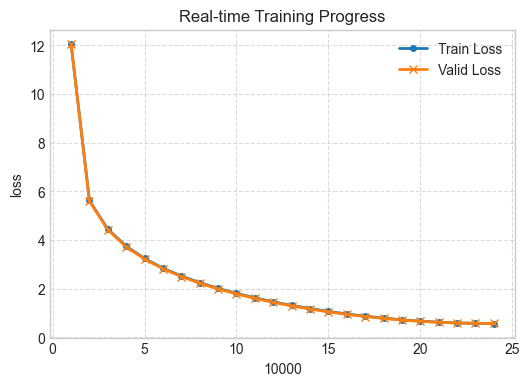

early stop
train time: 667.80
第 5 折训练集RMSE: 0.5661, 验证集RMSE: 0.5739
5-折交叉验证平均训练集RMSE: 0.5685, 平均验证集RMSE: 0.5695


In [53]:
total_train_ls, total_test_ls = k_fold(5,x,y,10000,1e-3,2,256)

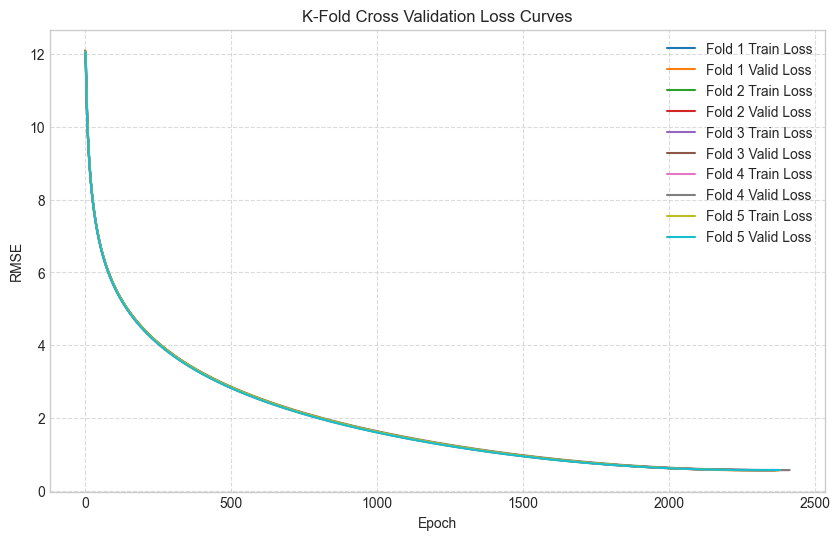

In [54]:
plt.figure(figsize=(10,6))
for i in range(5):
    plt.plot(total_train_ls[i], label=f'Fold {i+1} Train Loss')
    plt.plot(total_test_ls[i], label=f'Fold {i+1} Valid Loss')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('K-Fold Cross Validation Loss Curves')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [67]:
net=Net(in_features)
net.to(device)
y=y.reshape(-1,1)
train_ls,_ = train(net,0,DataLoader(ArrayDataset(x,y),batch_size=256,num_workers=0,shuffle=True),[],10000,1e-3,2,temperature=100)

epoch 0, train loss 11.7700, time: 0.32s, lr: 0.0010
epoch 1000, train loss 4.4885, time: 0.25s, lr: 0.0010
epoch 2000, train loss 0.1747, time: 0.24s, lr: 0.0009
early stop
train time: 561.43


In [68]:
test_predictions=[]
net.eval()
net.load_state_dict(torch.load('california_0_best_model.pth'))
test_loader=DataLoader(ArrayDataset(test_features),batch_size=256,num_workers=0,shuffle=False)
for test_features in test_loader:
    test_features=test_features.to('cuda')
    test_predictions.append(net(test_features))

test_predictions=torch.cat(test_predictions,dim=0).cpu().detach().numpy()
submission=pd.DataFrame({'Id':list(range(test_datas.shape[0])), 'median_house_value':test_predictions.reshape(-1)})
submission.to_csv('submission.csv',index=False)